In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

df = pd.read_csv("../data/processed/cleaned_telco.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (7043, 33)


,CustomerID,Count,Country,State,City,Zip_Code,Lat_Long,Latitude,Longitude,Gender,...,Contract,Paperless_Billing,Payment_Method,Monthly_Charges,Total_Charges,Churn_Label,Churn_Value,Churn_Score,CLTV,Churn_Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip_Code           7043 non-null   int64  
 6   Lat_Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior_Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure_Months      7043 non-null   int64  
 14  Phone_Service      7043 non-null   object 
 15  Multiple_Lines     7043 non-null   object 
 16  Internet_Service   7043 

In [3]:
df.isnull().sum().sort_values(ascending=False).head(10)

Churn_Reason    5174
CustomerID         0
Count              0
State              0
Country            0
Zip_Code           0
Lat_Long           0
Latitude           0
City               0
Gender             0
dtype: int64

In [4]:
df.isnull().sum().sort_values(ascending=False).head(10)

Churn_Reason    5174
CustomerID         0
Count              0
State              0
Country            0
Zip_Code           0
Lat_Long           0
Latitude           0
City               0
Gender             0
dtype: int64

In [5]:
df.describe()

,Count,Zip_Code,Latitude,Longitude,Tenure_Months,Monthly_Charges,Total_Charges,Churn_Value,Churn_Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,2281.916928,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,2265.270398,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,18.800000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,402.225000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,1397.475000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,3786.600000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,8684.800000,1.000000,100.000000,6500.000000


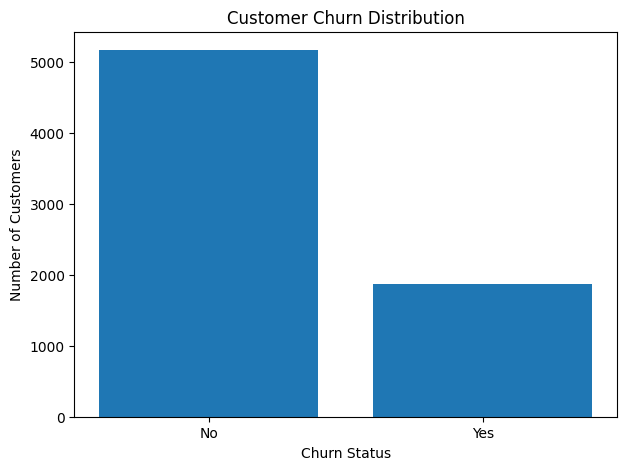

In [6]:
churn_counts = df["Churn_Label"].value_counts()

plt.figure(figsize=(7, 5))

plt.bar(
    churn_counts.index,
    churn_counts.values
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

plt.show()

### Insight

The customer base contains considerably more retained customers than churned customers. This imbalance should be considered when evaluating future churn prediction models.

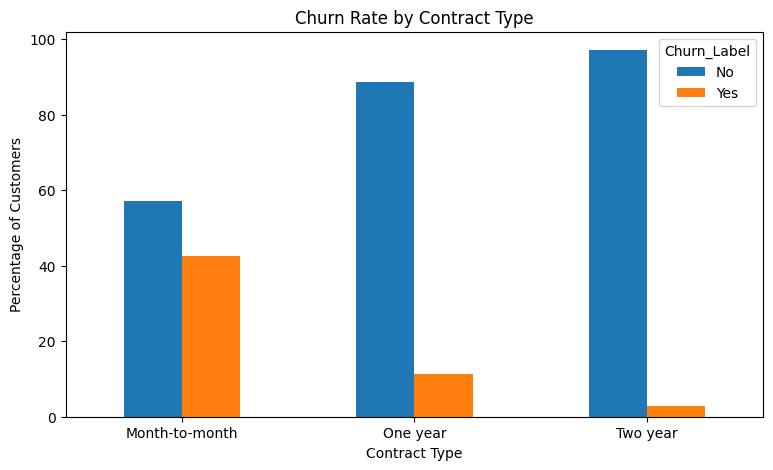

In [7]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn_Label"],
    normalize="index"
) * 100

contract_churn.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=0)

plt.show()

### Insight

Month-to-month customers demonstrate substantially greater churn risk, while customers on longer-term contracts show stronger retention.

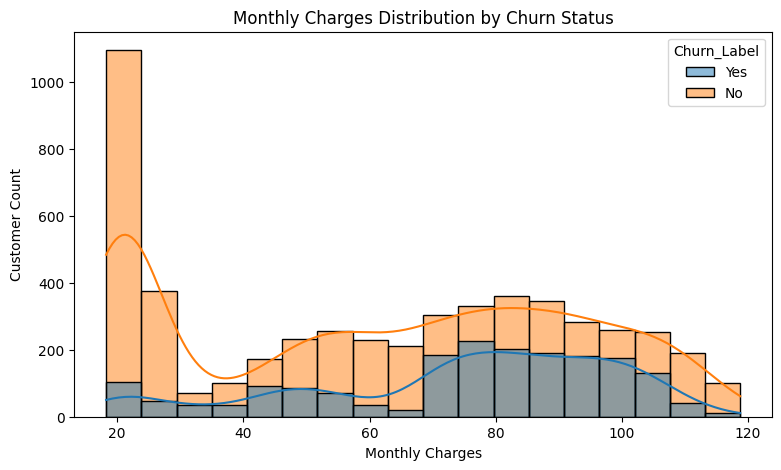

In [8]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="Monthly_Charges",
    hue="Churn_Label",
    kde=True
)

plt.title("Monthly Charges Distribution by Churn Status")
plt.xlabel("Monthly Charges")
plt.ylabel("Customer Count")

plt.show()

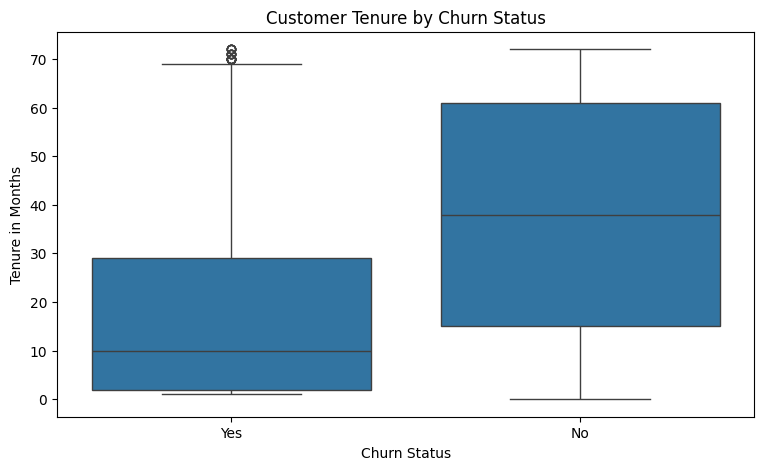

In [9]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Churn_Label",
    y="Tenure_Months"
)

plt.title("Customer Tenure by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Tenure in Months")

plt.show()

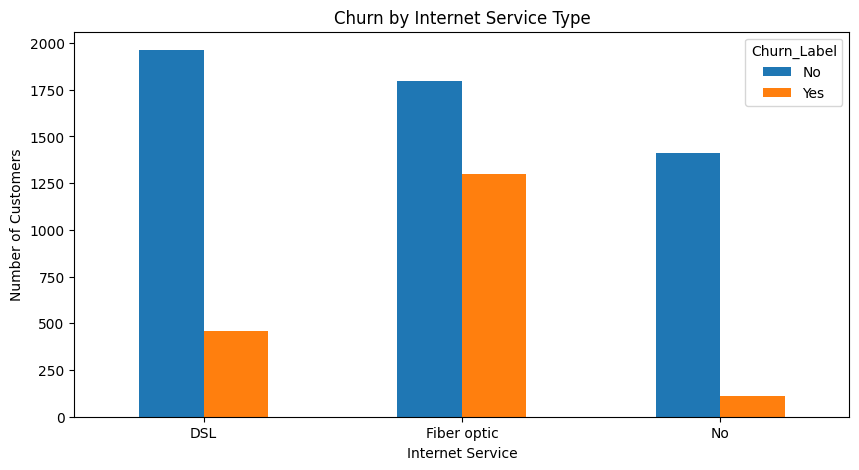

In [10]:
internet_churn = pd.crosstab(
    df["Internet_Service"],
    df["Churn_Label"]
)

internet_churn.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Churn by Internet Service Type")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.show()

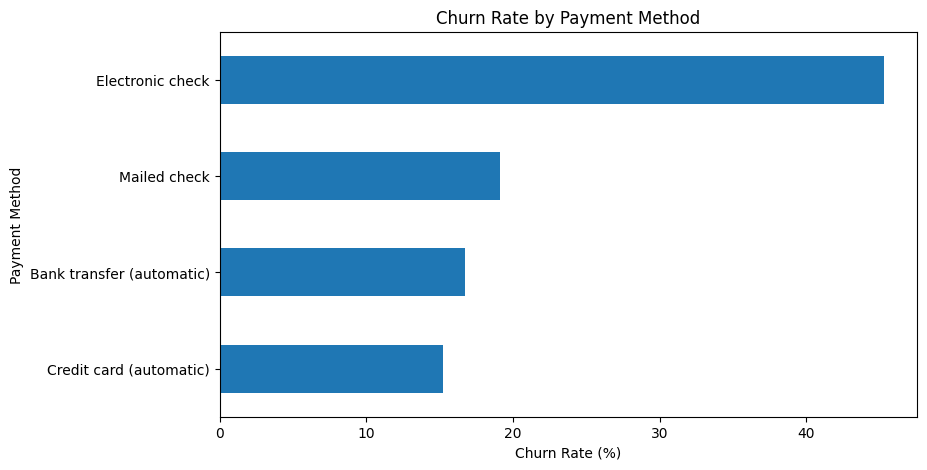

In [11]:
payment_churn = pd.crosstab(
    df["Payment_Method"],
    df["Churn_Label"],
    normalize="index"
) * 100

payment_churn["Yes"].sort_values().plot(
    kind="barh",
    figsize=(9, 5)
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Churn Rate (%)")
plt.ylabel("Payment Method")

plt.show()

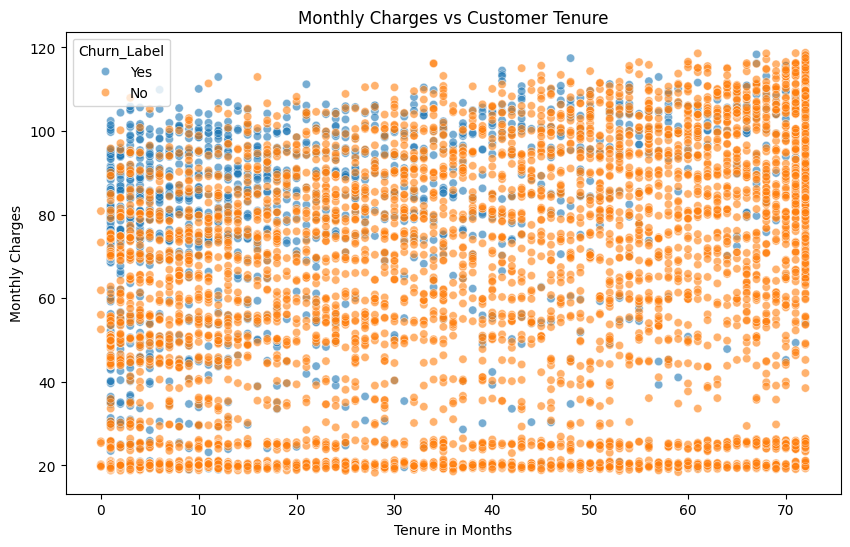

In [12]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Tenure_Months",
    y="Monthly_Charges",
    hue="Churn_Label",
    alpha=0.6
)

plt.title("Monthly Charges vs Customer Tenure")
plt.xlabel("Tenure in Months")
plt.ylabel("Monthly Charges")

plt.show()

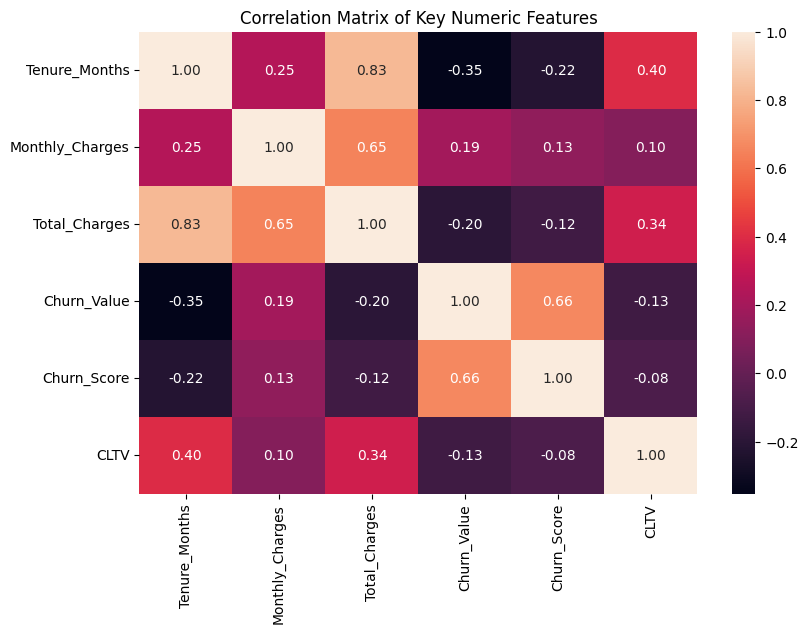

In [13]:
numeric_columns = [
    "Tenure_Months",
    "Monthly_Charges",
    "Total_Charges",
    "Churn_Value",
    "Churn_Score",
    "CLTV"
]

correlation = df[numeric_columns].corr()

plt.figure(figsize=(9, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix of Key Numeric Features")

plt.show()

In [14]:
df["Senior_Citizen"].value_counts()

Senior_Citizen
No     5901
Yes    1142
Name: count, dtype: int64

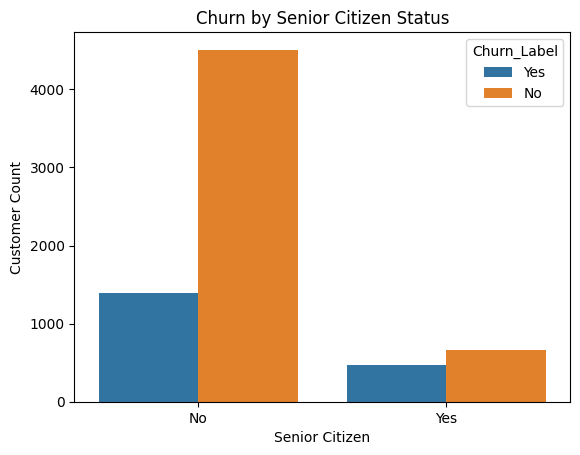

In [15]:
sns.countplot(
    data=df,
    x="Senior_Citizen",
    hue="Churn_Label"
)

plt.title("Churn by Senior Citizen Status")
plt.xlabel("Senior Citizen")
plt.ylabel("Customer Count")

plt.show()

In [16]:
import plotly.express as px

fig = px.histogram(
    df,
    x="Contract",
    color="Churn_Label",
    barmode="group",
    title="Customer Churn by Contract Type"
)

fig.show()

fig.write_html("../dashboards/churn_by_contract.html")

In [17]:
fig = px.histogram(
    df,
    x="Monthly_Charges",
    color="Churn_Label",
    marginal="box",
    title="Monthly Charges Distribution"
)

fig.show()

fig.write_html("../dashboards/monthly_charges_distribution.html")

In [18]:
fig = px.scatter(
    df,
    x="Tenure_Months",
    y="Monthly_Charges",
    color="Churn_Label",
    hover_data=["Contract","Internet_Service"],
    title="Monthly Charges vs Tenure"
)

fig.show()

fig.write_html("../dashboards/scatter_tenure.html")

In [19]:
fig = px.sunburst(
    df,
    path=["Contract","Internet_Service","Churn_Label"],
    title="Customer Distribution"
)

fig.show()

fig.write_html("../dashboards/customer_distribution.html")

In [20]:
fig = px.scatter_map(
    df,
    lat="Latitude",
    lon="Longitude",
    color="Churn_Label",
    hover_name="City",
    zoom=3,
    title="Customer Locations"
)

fig.show()

fig.write_html("../dashboards/customer_map.html")

In [21]:
fig = px.scatter_mapbox(
    df,
    lat="Latitude",
    lon="Longitude",
    color="Churn_Label",
    hover_name="City",
    zoom=3,
    mapbox_style="open-street-map",
    title="Customer Locations"
)

fig.show()
fig.write_html("../dashboards/customer_map.html")

C:\Users\purua\AppData\Local\Temp\ipykernel_39764\2510205054.py:1: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


In [22]:
fig = px.box(
    df,
    x="Churn_Label",
    y="CLTV",
    color="Churn_Label",
    title="Customer Lifetime Value by Churn"
)

fig.show()

fig.write_html("../dashboards/cltv_analysis.html")